#### 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Darstellungsoptionen
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print("Setup abgeschlossen.")

Setup abgeschlossen.


#### 2. Import
- OSMI Mental Health in Tech Survey 2016 
- https://www.kaggle.com/osmi/mental-health-in-tech-2016

In [2]:
# Pfad anpassen, falls noetig
df = pd.read_csv("../data/raw/mental-health-in-tech-2016_20161114.csv")
print(f"Datensatz geladen: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")

Datensatz geladen: 1433 Zeilen, 63 Spalten


#### 3. Datenstruktur

- Spaltennamen + 3 Zeilen

In [3]:
df.head(3)

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Do you feel that your employer takes mental health as seriously as physical health?,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you know local or online resources to seek help for a mental health disorder?,"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?","If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?","If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?","If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?",Do you believe your productivity is ever affected by a mental health issue?,"If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",Do you have previous employers?,Have your previous employers provided mental health benefits?,Were you aware of the options for mental health care provided by your previous employers?,Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Do you think that discussing a physical health issue with previous employers would have negative consequences?,Would you have been willing to discuss a mental health issue with your previous co-workers?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Would you be willing to bring up a physical health issue with a potential employer in an interview?,Why or why not?,Would you bring up a mental health issue with a potential employer in an interview?,Why or why not?.1,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a menta

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 63 columns):
 #   Column                                                                                                                                                                            Non-Null Count  Dtype  
---  ------                                                                                                                                                                            --------------  -----  
 0   Are you self-employed?                                                                                                                                                            1433 non-null   int64  
 1   How many employees does your company or organization have?                                                                                                                        1146 non-null   str    
 2   Is your employer primarily a tech company/organization?                

#### Spaltennamen kürzen

In [5]:
sys.path.append("../src")
from column_aliases import COLUMN_ALIASES

df.rename(columns={k: v for k, v in COLUMN_ALIASES.items() if k in df.columns}, inplace=True)
if "Why or why not?.1" in df.columns:
    df.rename(columns={"Why or why not?.1": "interview_mental_why"}, inplace=True)

#### 4. Fehlende Werte

- Fragen wurden nicht beantwortet
- Selbstständige haben keinen Arbeitgeber, Antworten fehlen
- Einige Fragen werden nur bestimmten Personen gestellt (?)

#### Analyse
- Einige Spalten haben exakt 287 fehlende Werte (20%)
- entspricht der Anzahl der Selbstständigen im Datensatz (`self_employed == 1`). 
- 169 Personen hatten / nennen keine früheren Arbeitgeber (`has_previous_employers == 0`), 
- da wo mehr als der Werte fehlen (`reveal_clients`, `productivity_affected`) wurden die Fragen vermutlich nicht gestellt -> im Preprocessing entfernen?

In [6]:
# Fehlende Werte pro Spalte
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({
    'Fehlend': missing,
    'Prozent': missing_pct
}).sort_values('Fehlend', ascending=False)

# Nur Spalten mit fehlenden Werten anzeigen
missing_df[missing_df['Fehlend'] > 0]

,Fehlend,Prozent
reveal_clients_impact,1289,90.0
pct_work_affected,1229,85.8
tech_role,1170,81.6
Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,1146,80.0
reveal_clients,1146,80.0
reveal_coworkers,1146,80.0
reveal_coworkers_impact,1146,80.0
know_resources,1146,80.0
productivity_affected,1146,80.0
believed_conditions,1111,77.5


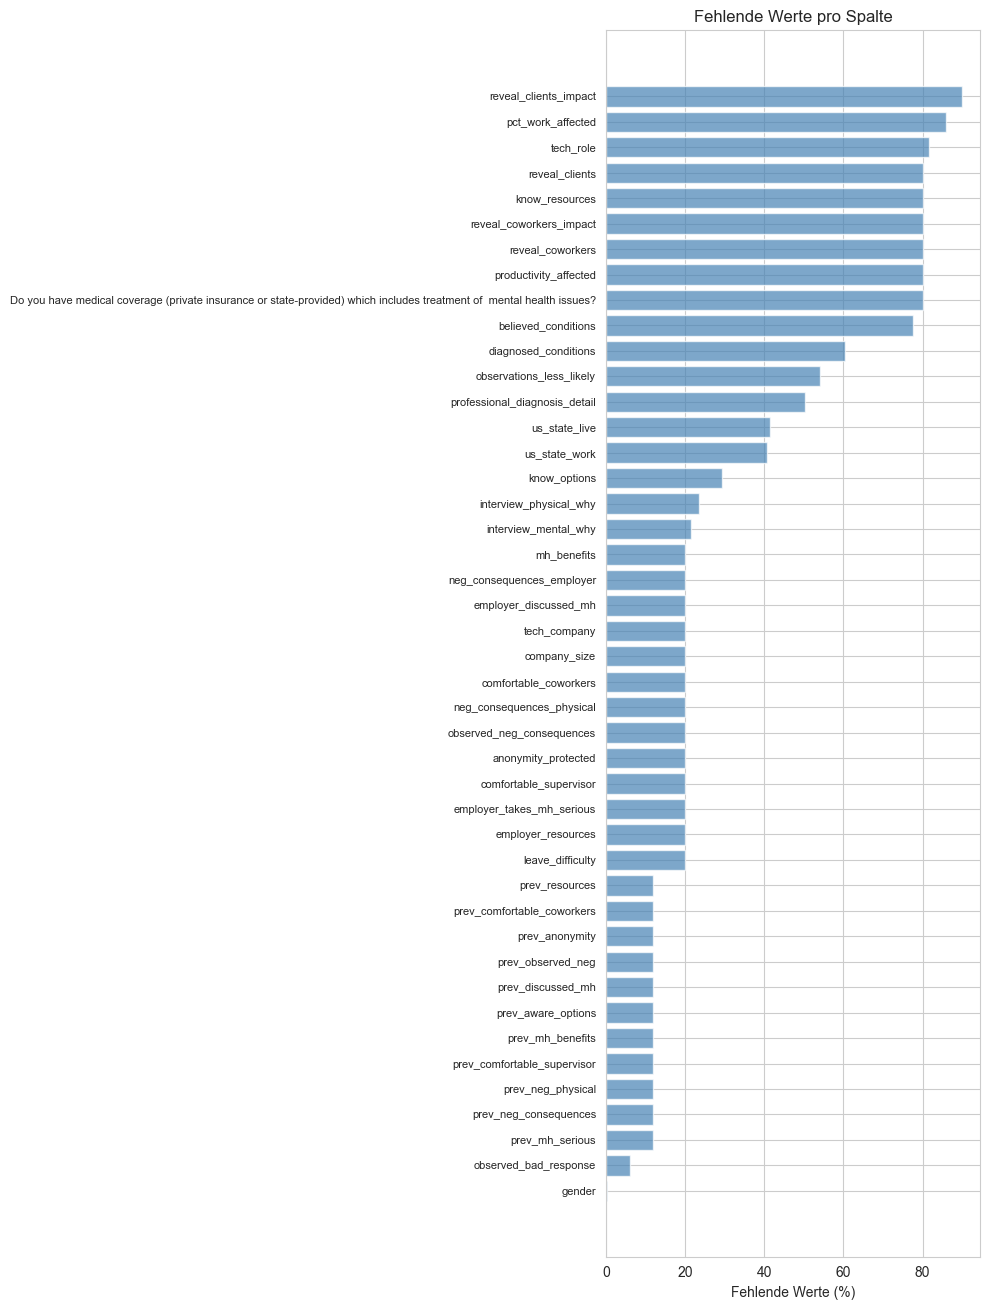

In [7]:
# Fehlende Werte, Verteilung
missing_plot = missing_df[missing_df['Fehlend'] > 0].sort_values('Fehlend', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(missing_plot) * 0.3)))
ax.barh(range(len(missing_plot)), missing_plot['Prozent'], color='steelblue', alpha=0.7)
ax.set_yticks(range(len(missing_plot)))
ax.set_yticklabels(missing_plot.index, fontsize=8)
ax.set_xlabel('Fehlende Werte (%)')
ax.set_title('Fehlende Werte pro Spalte')
plt.tight_layout()
plt.show()

In [8]:
# Testen: Fehlende Werte bei Arbeitgeberfragen = Selbststaendige
n_self_employed = (df['self_employed'] == 1).sum()
n_missing_company_size = df['company_size'].isnull().sum()

print(f"Anzahl Selbststaendige: {n_self_employed}")
print(f"Fehlende Werte bei company_size: {n_missing_company_size}")
print(n_self_employed == n_missing_company_size)

Anzahl Selbststaendige: 287
Fehlende Werte bei company_size: 287
True


#### 5. Datentypen und Variablenarten

Hauptsächlich: Ja/Nein, Likert-Skalen, Freitext 
Numerisch: Alter 

In [9]:
# Uebersicht Datentypen
print("Datentypen:")
print(df.dtypes.value_counts())
print(f"\nGesamtzahl Spalten: {len(df.columns)}")

Datentypen:
str        56
int64       4
float64     3
Name: count, dtype: int64

Gesamtzahl Spalten: 63


#### 6. Alter
- Teils unplausible Antworten
- Ausreißer prüfen

In [10]:
print(df['age'].describe())

count    1433.000000
mean       34.286113
std        11.290931
min         3.000000
25%        28.000000
50%        33.000000
75%        39.000000
max       323.000000
Name: age, dtype: float64


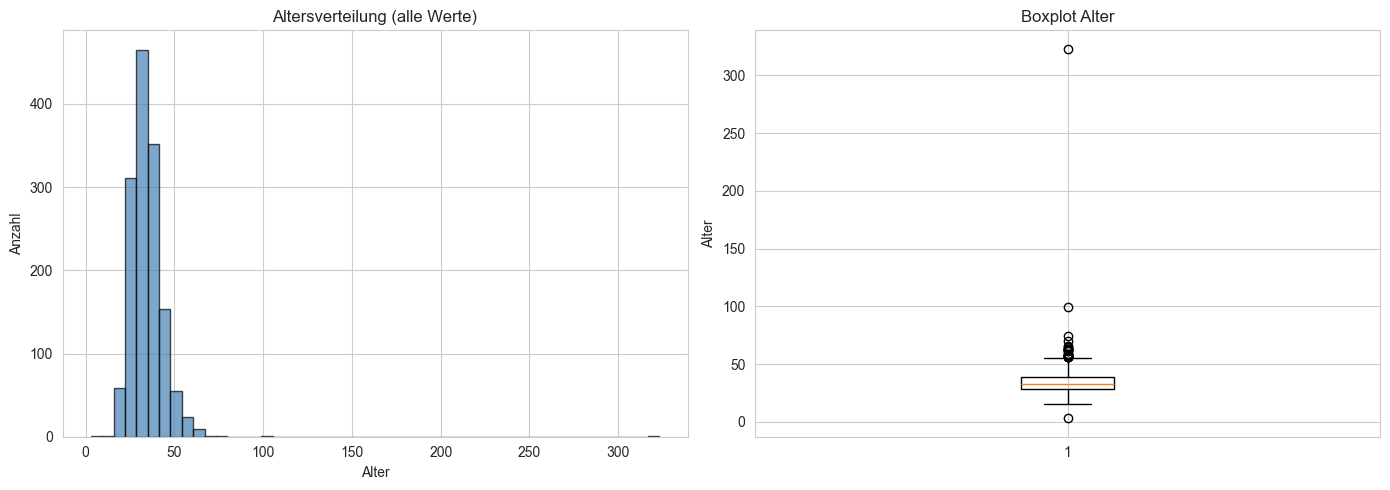

In [11]:
# Altersverteilung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramm (alle Werte)
axes[0].hist(df['age'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Alter')
axes[0].set_ylabel('Anzahl')
axes[0].set_title('Altersverteilung (alle Werte)')

# Boxplot
axes[1].boxplot(df['age'].dropna(), vert=True)
axes[1].set_ylabel('Alter')
axes[1].set_title('Boxplot Alter')

plt.tight_layout()
plt.show()

In [12]:
# Ausreisser
outliers = df[(df['age'] < 18) | (df['age'] > 80)]
print(f"Ausreisser (< 18 oder > 80): {len(outliers)}")
print(f"Werte: {sorted(outliers['age'].unique())}")

Ausreisser (< 18 oder > 80): 5
Werte: [np.int64(3), np.int64(15), np.int64(17), np.int64(99), np.int64(323)]


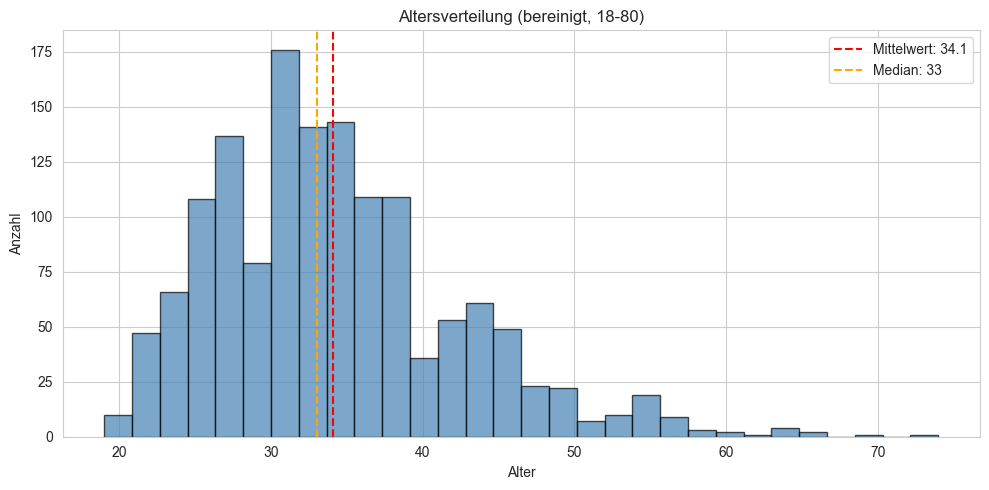

In [13]:
# Altersverteilung ohne Ausreisser
ages_clean = df['age'][(df['age'] >= 18) & (df['age'] <= 80)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ages_clean, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Alter')
ax.set_ylabel('Anzahl')
ax.set_title('Altersverteilung (bereinigt, 18-80)')
ax.axvline(ages_clean.mean(), color='red', linestyle='--', label=f'Mittelwert: {ages_clean.mean():.1f}')
ax.axvline(ages_clean.median(), color='orange', linestyle='--', label=f'Median: {ages_clean.median():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

#### 7. Gender = Freitext
- muss später vereinheitlicht werden

In [14]:
print(f"Anzahl unique Rohwerte: {df['gender'].nunique()}")
print(f"Fehlende Werte: {df['gender'].isnull().sum()}")
print(f"\nAlle Werte und Haeufigkeiten:")
print(df['gender'].value_counts().to_string())

Anzahl unique Rohwerte: 70
Fehlende Werte: 3

Alle Werte und Haeufigkeiten:
gender
Male                                                                                                                                                             610
male                                                                                                                                                             249
Female                                                                                                                                                           153
female                                                                                                                                                            95
M                                                                                                                                                                 86
m                                                                                           

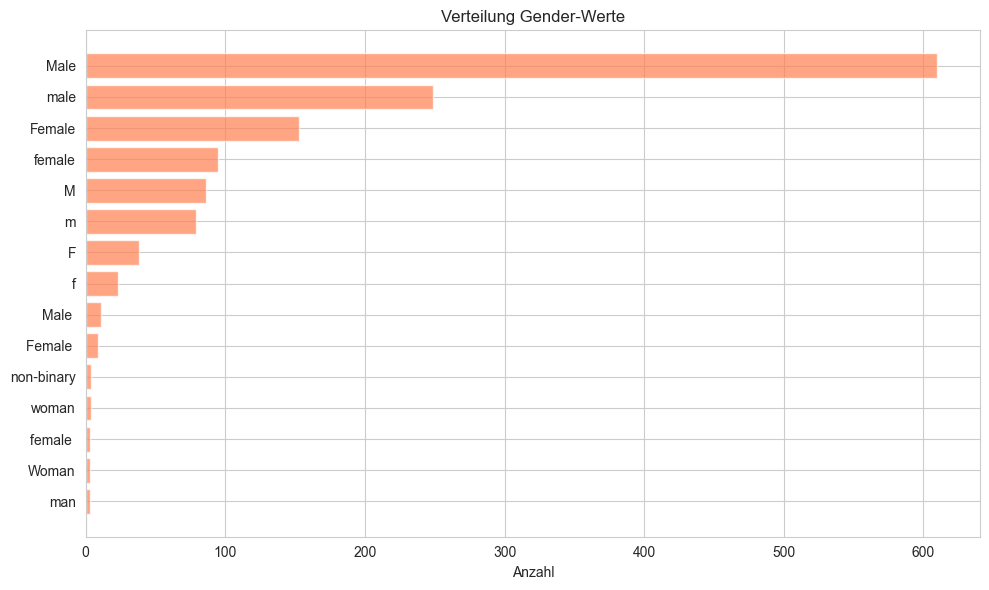

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
top_gender = df['gender'].value_counts().head(15)
ax.barh(range(len(top_gender)), top_gender.values, color='coral', alpha=0.7)
ax.set_yticks(range(len(top_gender)))
ax.set_yticklabels(top_gender.index)
ax.set_xlabel('Anzahl')
ax.set_title('Verteilung Gender-Werte')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

#### 8. Geographische Verteilung
- Regionen aggregieren?

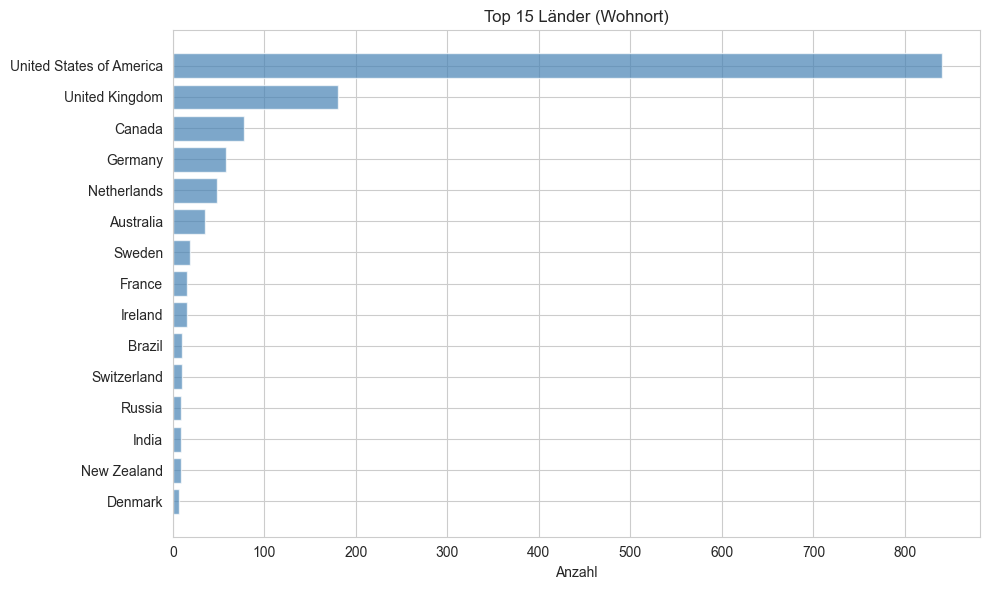


Anzahl verschiedene Laender: 53
Anteil USA: 58.6%


In [16]:
# Top-15 Laender
fig, ax = plt.subplots(figsize=(10, 6))
countries = df['country_live'].value_counts().head(15)
ax.barh(range(len(countries)), countries.values, color='steelblue', alpha=0.7)
ax.set_yticks(range(len(countries)))
ax.set_yticklabels(countries.index)
ax.set_xlabel('Anzahl')
ax.set_title('Top 15 Länder (Wohnort)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nAnzahl verschiedene Laender: {df['country_live'].nunique()}")
print(f"Anteil USA: {(df['country_live'] == 'United States of America').sum() / len(df) * 100:.1f}%")

#### 9. Wer ist in Behandlung?

In [17]:
# Kreuztabelle: Aktuelle Stoerung vs. Behandlung gesucht
ct = pd.crosstab(df['current_disorder'], df['sought_treatment'], margins=True)
print("Aktuelle MH-Störung vs. Behandlung gesucht:")
print(ct)

Aktuelle MH-Störung vs. Behandlung gesucht:
sought_treatment    0    1   All
current_disorder                
Maybe             145  182   327
No                390  141   531
Yes                59  516   575
All               594  839  1433


#### 10. Negative Konsequenzen bei Gespräch mit AG befürchtet

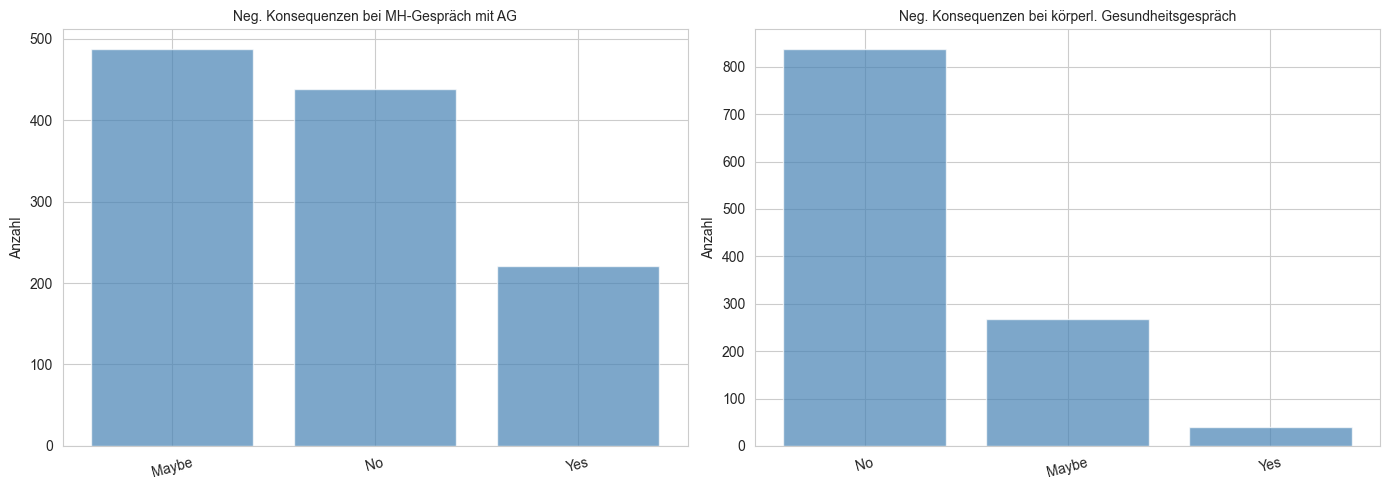

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (col, title) in enumerate([
    ('neg_consequences_employer', 'Neg. Konsequenzen bei MH-Gespräch mit AG'),
    ('neg_consequences_physical', 'Neg. Konsequenzen bei körperl. Gesundheitsgespräch')
]):
    if col in df.columns:
        counts = df[col].value_counts()
        axes[i].bar(range(len(counts)), counts.values, color='steelblue', alpha=0.7)
        axes[i].set_xticks(range(len(counts)))
        axes[i].set_xticklabels(counts.index, rotation=15)
        axes[i].set_title(title, fontsize=10)
        axes[i].set_ylabel('Anzahl')

plt.tight_layout()
plt.show()

#### 11. Andere Verteilungen prüfen:
Selbstständige, Unternehmensgröße, Unterstützung durch AG bei MH Problemen, Erwartete Konsequenzen, ...

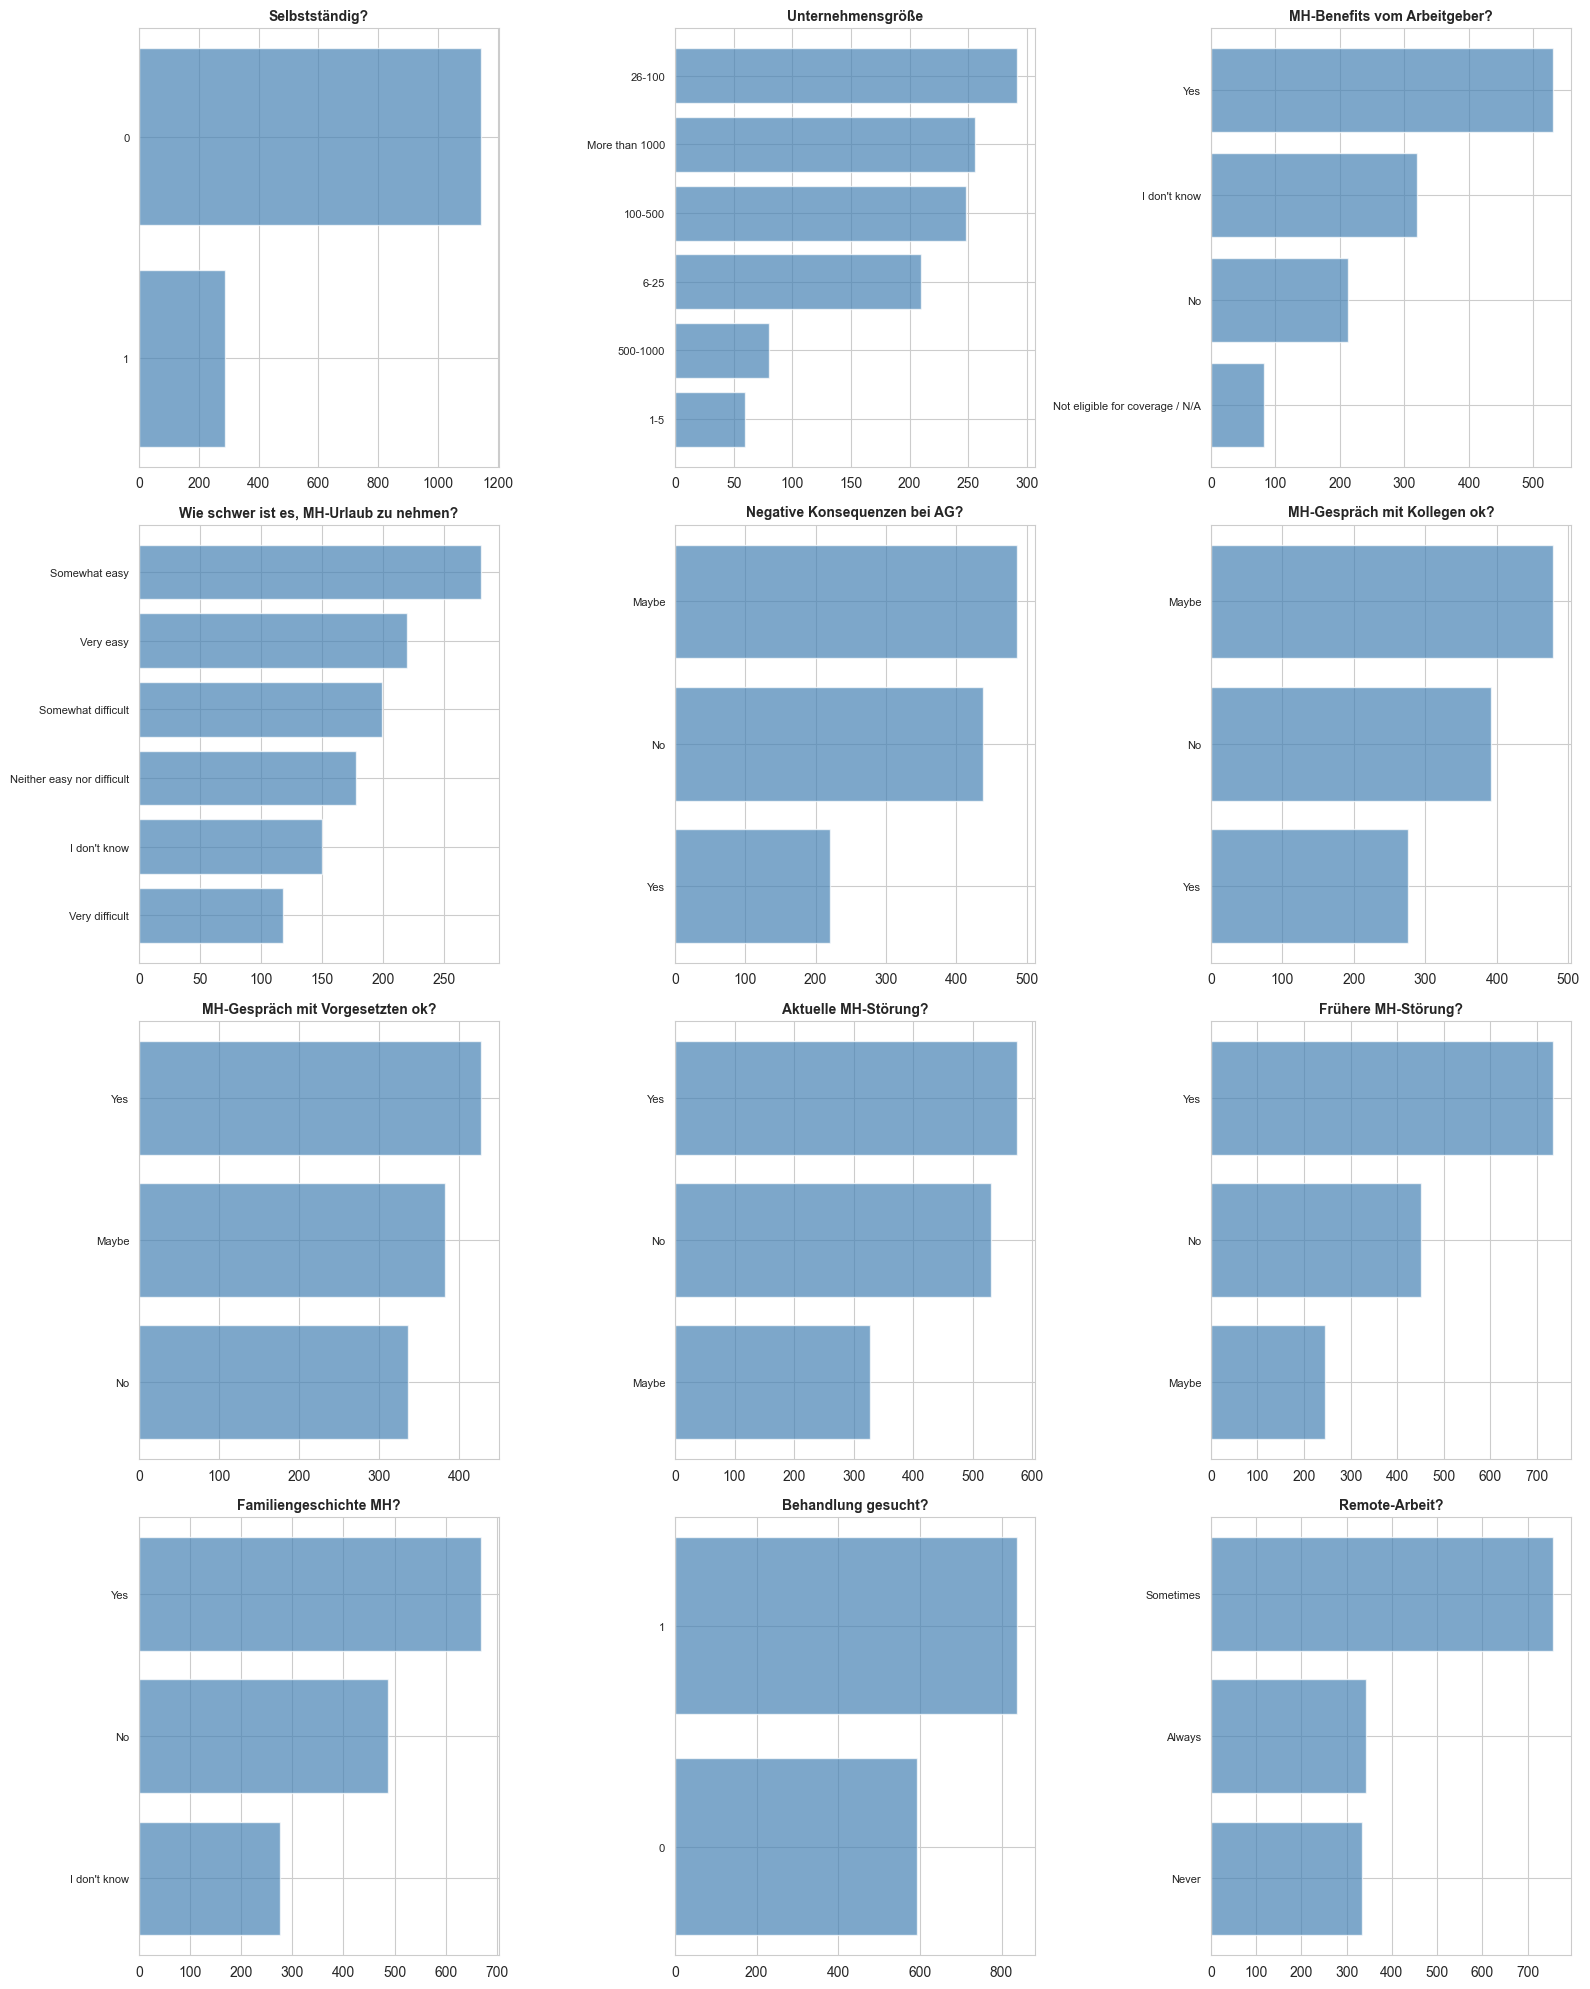

In [19]:
# Auswahl relevanter Spalten fuer Visualisierung
plot_cols = [
    ('self_employed', 'Selbstständig?'),
    ('company_size', 'Unternehmensgröße'),
    ('mh_benefits', 'MH-Benefits vom Arbeitgeber?'),
    ('leave_difficulty', 'Wie schwer ist es, MH-Urlaub zu nehmen?'),
    ('neg_consequences_employer', 'Negative Konsequenzen bei AG?'),
    ('comfortable_coworkers', 'MH-Gespräch mit Kollegen ok?'),
    ('comfortable_supervisor', 'MH-Gespräch mit Vorgesetzten ok?'),
    ('current_disorder', 'Aktuelle MH-Störung?'),
    ('past_disorder', 'Frühere MH-Störung?'),
    ('family_history', 'Familiengeschichte MH?'),
    ('sought_treatment', 'Behandlung gesucht?'),
    ('remote_work', 'Remote-Arbeit?'),
]

fig, axes = plt.subplots(4, 3, figsize=(16, 20))
axes = axes.flatten()

for i, (col, title) in enumerate(plot_cols):
    if col in df.columns:
        counts = df[col].value_counts()
        axes[i].barh(range(len(counts)), counts.values, color='steelblue', alpha=0.7)
        axes[i].set_yticks(range(len(counts)))
        axes[i].set_yticklabels(counts.index, fontsize=8)
        axes[i].set_title(title, fontsize=10, fontweight='bold')
        axes[i].invert_yaxis()

plt.tight_layout()
plt.show()